# Birth Curves

## Definitions

For the Delaunay lower-star construction, see the
[Delaunay Lowerstar filtrations](../filtrations/function_delaunay.ipynb)
notebook. The Delaunay example at the end of this notebook is taken from
there and reused here to display birth curves.

For a 2-parameter grid module $M$, birth curves encode where classes can be
born. Algebraically, they are the indecomposable spread-curve summands of

$$
\ker\bigl(M \xrightarrow{xy} M(1,1)\bigr).
$$

If a homology module has a
[minimal presentation](../ops/minimal_presentations_resolutions.ipynb)

$$
R \longrightarrow G \longrightarrow M \longrightarrow 0,
$$

then `multipers.invariants.birth_curves` follows the presentation-level
algorithm

$$
R \oplus G[1] \longrightarrow G \longrightarrow
\bigoplus_i C_i \longrightarrow 0.
$$

Here $G[1]$ is the copy of each generator shifted by one grid step in both
coordinates, clipped at the grid-infinity sentinel. The
[AIDA backend](../ops/AIDA.ipynb) then decomposes this new presentation into
indecomposable interval/spread-curve summands $C_i$, and the public function
returns one polygonal vertex set for each summand.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import multipers as mp
import multipers.invariants as mpi

## Synthetic graph

Work over a field $\mathbb k$. Consider the small bifiltered graph with
vertices

$$
v_0@(0,0),\qquad v_1@(1,0),\qquad v_2@(0,1),
$$

and edges

$$
e_{01}@(1,1),\qquad e_{02}@(1,1).
$$

First build this graph as a `SimplexTreeMulti`.

In [2]:
st = mp.SimplexTreeMulti(num_parameters=2)
st.insert([0], [0.0, 0.0])
st.insert([1], [1.0, 0.0])
st.insert([2], [0.0, 1.0])
st.insert([0, 1], [1.0, 1.0])
st.insert([0, 2], [1.0, 1.0])

grid = (np.array([0.0, 1.0, 2.0]), np.array([0.0, 1.0, 2.0]))
slicer = mp.Slicer(st, dtype=np.float64).grid_squeeze(grid)

## Minimal presentation

In degree $0$, the simplicial presentation first has generators
$v_0,v_1,v_2$ and relations $\partial e_{01}=v_1-v_0$,
$\partial e_{02}=v_2-v_0$ at grade $(1,1)$. Changing basis to

$$
a=v_0,
\qquad b=v_1-v_0,
\qquad c=v_2-v_0
$$

gives the minimal presentation

$$
R \longrightarrow G \longrightarrow M \longrightarrow 0
$$

with

$$
G=\mathbb k(-(0,0))a
\oplus \mathbb k(-(1,0))b
\oplus \mathbb k(-(0,1))c,
$$

$$
R=\mathbb k(-(1,1))\rho_b
\oplus \mathbb k(-(1,1))\rho_c,
$$

and differential

$$
\rho_b \mapsto b,
\qquad
\rho_c \mapsto c.
$$

Thus $a$ is the persistent connected component, while $b$ and $c$ are the two
transient components killed when the edges appear at $(1,1)$.

Now compute the same minimal presentation with `multipers`; see also the
[minimal-presentation notebook](../ops/minimal_presentations_resolutions.ipynb).

<Axes: >

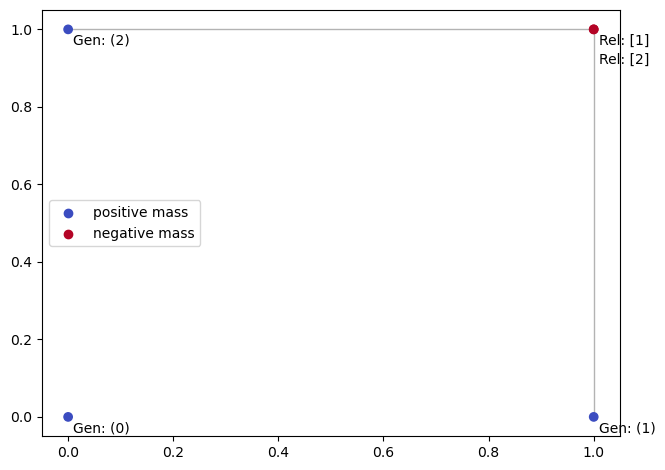

In [3]:
minpres = mp.ops.minimal_presentation(
    slicer,
    degree=0,
    full_resolution=True,
    force=True,
)

plt.figure()
mp.plots.plot_presentation(minpres)

## Updated presentation

For birth curves, replace $R \to G$ with

$$
R \oplus G[1] \longrightarrow G.
$$

On this grid, shifting by $[1]$ adds one grid step in both coordinates; crossing
the grid boundary is written as $\infty$. Hence

$$
a[1]@(1,1),
\qquad b[1]@(\infty,1),
\qquad c[1]@(1,\infty).
$$

The updated presentation has the same target module $G$, and relation module

$$
R\oplus G[1]
=\mathbb k(-(1,1))\rho_b
\oplus \mathbb k(-(1,1))\rho_c
\oplus \mathbb k(-(1,1))a'
\oplus \mathbb k(-(\infty,1))b'
\oplus \mathbb k(-(1,\infty))c'.
$$

Its differential is

$$
\rho_b\mapsto b,
\qquad \rho_c\mapsto c,
\qquad a'\mapsto a,
\qquad b'\mapsto b,
\qquad c'\mapsto c.
$$

From this updated presentation, the birth curves are read directly:

| generator | relations seen by the generator | birth curve vertices |
| --- | --- | --- |
| $a@(0,0)$ | $a'@(1,1)$ | $(0,0),(\infty,0),(0,\infty)$ |
| $b@(1,0)$ | $\rho_b@(1,1)$ and $b'@(\infty,1)$ | $(1,0),(\infty,0)$ |
| $c@(0,1)$ | $\rho_c@(1,1)$ and $c'@(1,\infty)$ | $(0,1),(0,\infty)$ |

The first curve is the corner born at $(0,0)$. The second is the horizontal
ray born at $(1,0)$, because $\rho_b$ kills it in the vertical direction at
$(1,1)$. The third is the vertical ray born at $(0,1)$, because $\rho_c$ kills
it in the horizontal direction at $(1,1)$.

In [4]:
expected_birth_curves = [
    np.array([[0.0, 0.0], [np.inf, 0.0], [0.0, np.inf]]),
    np.array([[1.0, 0.0], [np.inf, 0.0]]),
    np.array([[0.0, 1.0], [0.0, np.inf]]),
]
expected_birth_curves

[array([[ 0.,  0.],
        [inf,  0.],
        [ 0., inf]]),
 array([[ 1.,  0.],
        [inf,  0.]]),
 array([[ 0.,  1.],
        [ 0., inf]])]

## Birth curves from `multipers`

Finally, run `mpi.birth_curves` on the minimal presentation and compare the
output with the three curves obtained by hand. The comparison ignores the order
in which [AIDA](../ops/AIDA.ipynb) returns the summands and the vertex order inside
a curve.

<Axes: title={'center': 'Birth curves'}>

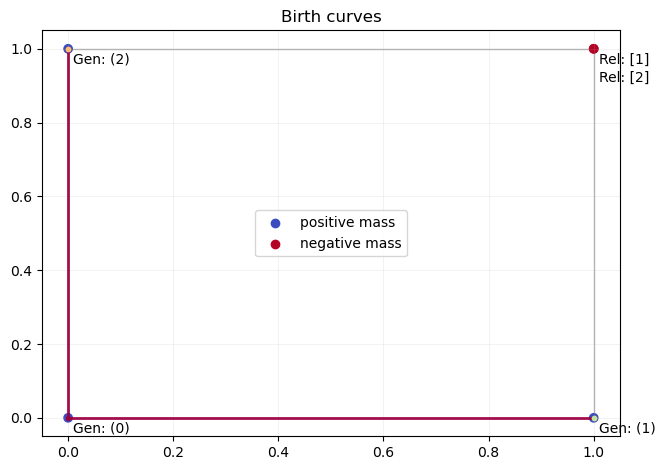

In [5]:
mpi.birth_curves(minpres, plot=True)
mp.plots.plot_presentation(minpres)

## Delaunay lower-star experiment

We now run the example from the
[Delaunay Lowerstar filtrations](../filtrations/function_delaunay.ipynb)
notebook. The scalar function is a negative log-density on a three-annulus
point cloud.

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


Text(0.5, 1.0, 'Three annuli colored by density')

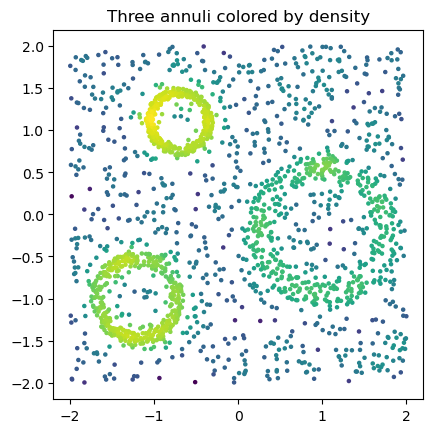

In [6]:
np.random.seed(0)
x = mp.data.three_annulus(1_000, 1_000)
f = -mp.filtrations.density.KDE(bandwidth=0.1, return_log=True).fit(x).score_samples(
    x
)

plt.scatter(*x.T, c=-f, s=5)
plt.gca().set_aspect(1)
plt.title("Three annuli colored by density")

The degree-1 Delaunay lower-star presentation can then be obtained by:

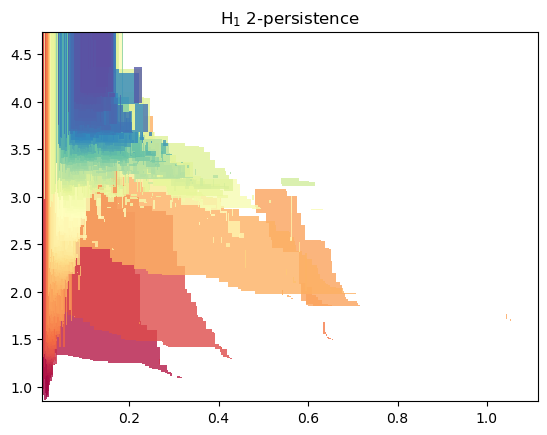

In [7]:
s = mp.filtrations.DelaunayLowerstar(points=x, function=f, reduce_degree=1)
mp.module_approximation(s).plot()

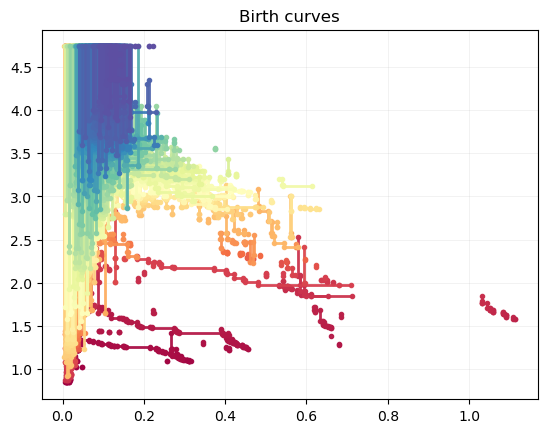

In [8]:
delaunay_birth_curves = mpi.birth_curves(s, plot=True)